# Imports
assumes in pathml singularity image

In [3]:
import os
import h5py
from pathml.ml import TileDataset
from torch.utils.data import DataLoader
import sys
from pathlib import Path
from PIL import Image
import numpy as np
import time
import matplotlib.pyplot as plt
scratch = os.getenv('SLURM_SCRATCH')
sp = Path(scratch)
sp.exists()

True

In [2]:
%%bash
cp "/ix/rbao/Projects/HCC-CBS-172-Hillman-RBao-HEseg/results/tile_h5/mel_2870.h5path" $SLURM_SCRATCH'/test.h5path'
ls -lh $SLURM_SCRATCH
echo "Finished"

total 560M
-rw-r--r-- 1 bri8 rbao 561M Sep 21 14:14 test.h5path
Finished


In [3]:
root = h5py.File(sp.joinpath('test.h5path'), 'r')

In [4]:
tile_shape = root['tiles'].attrs['tile_shape']
print(tile_shape)

(256, 256, 3)


In [6]:
[x for x in root.keys()]

['counts', 'fields', 'masks', 'tiles']

In [25]:
root['tiles']['(10240, 10240)']['array']

<HDF5 dataset "array": shape (256, 256, 3), type "<f2">

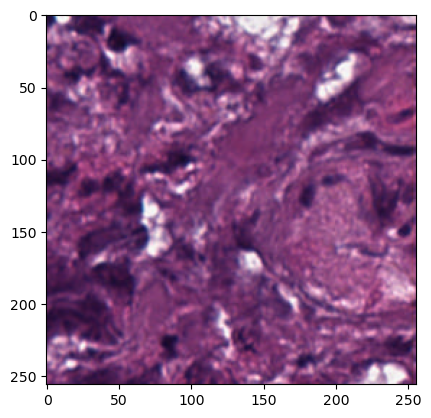

In [30]:
mask = root['tiles']['(10240, 10240)']['masks']['tissue']
im = np.array(root['tiles']['(10240, 10240)']['array'])
plt.imshow(im.astype(int))

In [31]:
fn=sp.joinpath('test.h5path')
dataset = TileDataset(fn)
dataloader = DataLoader(dataset,batch_size=10,shuffle=False,num_workers=1)

In [11]:
?dataset

Type:        TileDataset
String form: <pathml.ml.dataset.TileDataset object at 0x7f61628f7070>
Length:      1728
File:        /opt/conda/envs/py38/lib/python3.8/site-packages/pathml/ml/dataset.py
Docstring:  
PyTorch Dataset class for h5path files

Each item is a tuple of (``tile_image``, ``tile_masks``, ``tile_labels``, ``slide_labels``) where:

    - ``tile_image`` is a torch.Tensor of shape (C, H, W) or (T, Z, C, H, W)
    - ``tile_masks`` is a torch.Tensor of shape (n_masks, tile_height, tile_width)
    - ``tile_labels`` is a dict
    - ``slide_labels`` is a dict

This is designed to be wrapped in a PyTorch DataLoader for feeding tiles into ML models.

Note that label dictionaries are not standardized, as users are free to store whatever labels they want.
For that reason, PyTorch cannot automatically stack labels into batches.
When creating a DataLoader from a TileDataset, it may therefore be necessary to create a custom ``collate_fn`` to
specify how to create batches of labels. Se

batch = [image_batch, mask_batch, label_batch,slide_label_batch]

In [56]:
for i, batch in enumerate(dataloader):
    if i ==0 :
        print(len(batch),print(len(batch[0])))
        for item in batch[0]:
            print(item.shape)
        break;

10
4 None
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])
torch.Size([3, 256, 256])


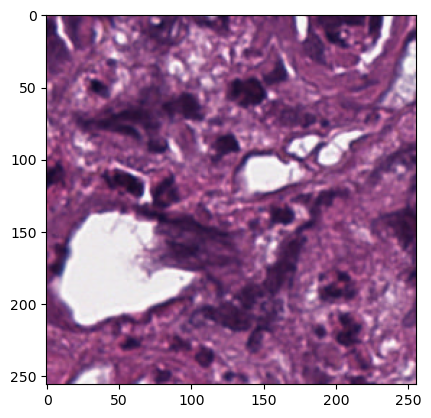

In [54]:
im = item.permute(1, 2, 0).numpy().astype(int)
plt.imshow(im)